In [4]:
# libraries
import pandas as pd
import numpy as np

In [5]:
#load data
data = pd.read_csv('../Data/spotify-tracks-dataset.csv')

In [6]:
#inspect data

data.head(30)

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
5,5,5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,...,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic
6,6,6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,...,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic
7,7,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,...,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic
8,8,8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,...,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic
9,9,9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,...,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic


In [7]:
#column names and data types
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  str    
 3   artists           113999 non-null  str    
 4   album_name        113999 non-null  str    
 5   track_name        113999 non-null  str    
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrumentalness  114000 non-nu

**Defining the various features:**

**Basic info:**

track_id — Spotify's unique id for the song
artists — artist name(s)
album_name — album it belongs to
track_name — song title
popularity — 0–100 score of how popular it is on Spotify right now
duration_ms — song length in milliseconds
explicit — whether it has explicit lyrics

**Audio features calculated by spotify:**

danceability — 0–1, how suitable for dancing (rhythm, beat strength)
energy — 0–1, intensity and activity (metal = high, classical = low)
loudness — average decibels, typically -60 to 0
tempo — BPM (beats per minute)
valence — 0–1, musical "happiness" (high = happy, low = sad/angry)
acousticness — 0–1, how acoustic vs electronic
instrumentalness — 0–1, likelihood of having no vocals
liveness — 0–1, likelihood it was recorded live
speechiness — 0–1, amount of spoken words (podcasts = high, music = low)

**Music theory**
key — musical key (0=C, 1=C#, 2=D... 11=B)
mode — 1=major (happy), 0=minor (sad)
time_signature — beats per measure (4 = most common)



In [8]:
#nulls and missing data -> not many nulls at all, data is relatively clean

data.isnull().sum()




Unnamed: 0.1        0
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [9]:
#EDA

# about track generes and their variability

print("Unique genres:", data['track_genre'].nunique())
print("Most common:", data['track_genre'].mode()[0]) # 
print("\nValue counts:\n", data['track_genre'].value_counts())
print("\nProportions:\n", data['track_genre'].value_counts(normalize=True))


# scrollable dataframe
genre_stats = pd.DataFrame({
    'count': data['track_genre'].value_counts(),
    'proportion': data['track_genre'].value_counts(normalize=True).round(4)
})

genre_stats

# viewing entire item as scrollable 
from IPython.display import display
with pd.option_context('display.max_rows', None):
    display(genre_stats)


#takeaway: 
#all 114 genres have 1000 tracks each.


Unique genres: 114
Most common: acoustic

Value counts:
 track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64

Proportions:
 track_genre
acoustic       0.008772
afrobeat       0.008772
alt-rock       0.008772
alternative    0.008772
ambient        0.008772
                 ...   
techno         0.008772
trance         0.008772
trip-hop       0.008772
turkish        0.008772
world-music    0.008772
Name: proportion, Length: 114, dtype: float64


,count,proportion
track_genre,,
acoustic,1000,0.0088
afrobeat,1000,0.0088
alt-rock,1000,0.0088
alternative,1000,0.0088
ambient,1000,0.0088
anime,1000,0.0088
black-metal,1000,0.0088
bluegrass,1000,0.0088
blues,1000,0.0088


In [10]:
#are there tracks/same songs that show up under multiple genres/sub genres?  

# checking for duplicate songs and seeing if it has different genre labeling
duplicates = data.groupby('track_id')['track_genre'].nunique()
multi_genre = duplicates[duplicates > 1]
print(f"tracks appearing in multiple genres: {len(multi_genre)}")

#16299 multigenred tracks

#view tracks
data[data['track_id'].isin(multi_genre.index)][['track_id', 'track_name', 'artists', 'track_genre']].sort_values('track_id')

#takeaway: when it comes to accuracy is it sufficientfor NN to be able to classify just one of the genres or should it be all genres that exist for the song

tracks appearing in multiple genres: 16299


,track_id,track_name,artists,track_genre
103211,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,soul
15028,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,chill
85578,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,punk-rock
100420,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,ska
91801,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,rock
...,...,...,...,...
72679,7zv2vmZq8OjS54BxFzI2wM,Lets Start the Party,Attila,metalcore
22326,7zv2vmZq8OjS54BxFzI2wM,Lets Start the Party,Attila,death-metal
3100,7zwn1eykZtZ5LODrf7c0tS,You Get Me So High,The Neighbourhood,alternative
91401,7zwn1eykZtZ5LODrf7c0tS,You Get Me So High,The Neighbourhood,rock


In [11]:
#EDA with base models to predict specified genres
#imports
import sys
!{sys.executable} -m pip install scikit-learn
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
import sys



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


PCA reduced features from 15 → 13 components
Best k = 29  (CV accuracy = 0.2135)


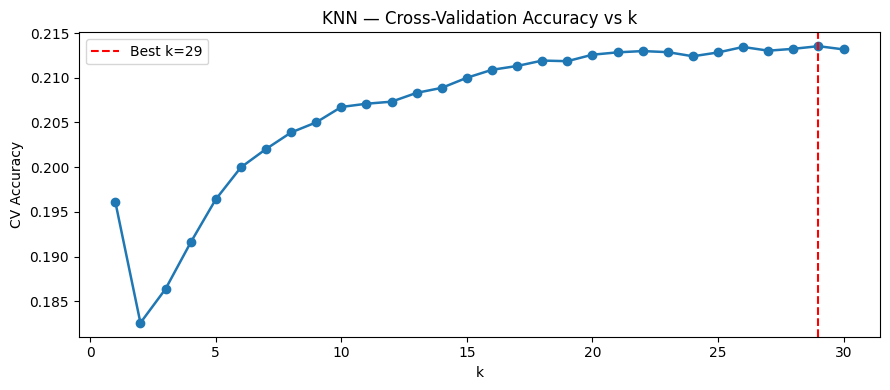

                   precision    recall  f1-score   support

         acoustic       0.09      0.18      0.13       200
         afrobeat       0.20      0.22      0.21       200
         alt-rock       0.04      0.04      0.04       200
      alternative       0.08      0.08      0.08       200
          ambient       0.20      0.20      0.20       200
            anime       0.06      0.08      0.07       200
      black-metal       0.36      0.44      0.40       200
        bluegrass       0.27      0.39      0.32       200
            blues       0.15      0.12      0.13       200
           brazil       0.05      0.04      0.04       200
        breakbeat       0.18      0.12      0.14       200
          british       0.04      0.02      0.03       200
         cantopop       0.15      0.24      0.19       200
    chicago-house       0.25      0.38      0.30       200
         children       0.35      0.29      0.32       200
            chill       0.12      0.14      0.13       

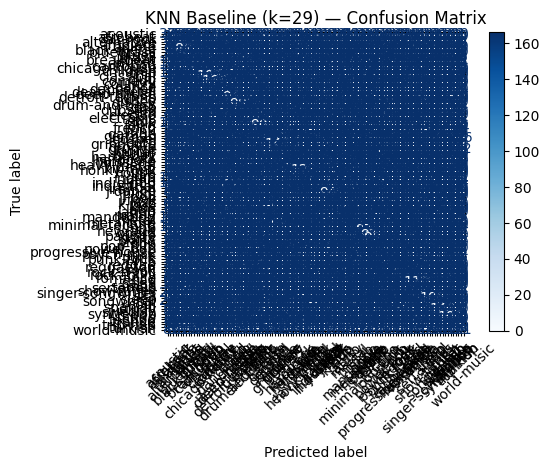

In [12]:
#Knn base model

#  features

audio_features = [
    "popularity", "duration_ms", "explicit",
    "danceability", "energy", "key", "loudness", "mode",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "time_signature"
]

# dropping target track genre column and nulls if present in feature list
df = data.dropna(subset=audio_features + ["track_genre"])


X = df[audio_features].values
y = LabelEncoder().fit_transform(df["track_genre"])
le = LabelEncoder().fit(df["track_genre"])

#  split into test and train and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# stratify = y keeps genre proportions balanced across the split

# scaling 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

#  PCA: keep 95% of variance 
pca = PCA(n_components=0.95, random_state=42)
X_train = pca.fit_transform(X_train)
X_test  = pca.transform(X_test)
print(f"PCA reduced features from {len(audio_features)} → {pca.n_components_} components")


# tune hyperparameters, k via cross-validation 
k_scores = {}
for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
    k_scores[k] = cross_val_score(knn, X_train, y_train, cv=5, scoring="accuracy").mean()

best_k = max(k_scores, key=k_scores.get)
print(f"Best k = {best_k}  (CV accuracy = {k_scores[best_k]:.4f})")

# plotting k curve
plt.figure(figsize=(9, 4))
plt.plot(k_scores.keys(), k_scores.values(), marker="o", linewidth=1.8)
plt.axvline(best_k, color="red", linestyle="--", label=f"Best k={best_k}")
plt.xlabel("k"); plt.ylabel("CV Accuracy")
plt.title("KNN — Cross-Validation Accuracy vs k")
plt.legend(); plt.tight_layout(); plt.show()

# train and evaluate with best k
knn = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean", n_jobs=-1)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_, cmap="Blues", xticks_rotation=45)
plt.title(f"KNN Baseline (k={best_k}) — Confusion Matrix")
plt.tight_layout(); plt.show()






#which features are most important in genre classification?


#evaluate 





Model is very bad, scores accuracy of 21%, going to try binning genres and subgenres. We can have model that bins into genre and model for each bin to find the subgenre

In [ ]:
#binned version

audio_features = [
    "popularity", "duration_ms", "explicit",
    "danceability", "energy", "key", "loudness", "mode",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "time_signature"
]

# genre binning
genre_map = {
    # Rock
    "rock": "rock", "alt-rock": "rock", "alternative": "rock",
    "hard-rock": "rock", "punk": "rock", "punk-rock": "rock",
    "grunge": "rock", "psych-rock": "rock", "power-pop": "rock",
    "rockabilly": "rock", "rock-n-roll": "rock", "british": "rock",

    # Metal
    "metal": "metal", "heavy-metal": "metal", "black-metal": "metal",
    "death-metal": "metal", "grindcore": "metal", "metalcore": "metal",
    "hardcore": "metal", "industrial": "metal",

    # Electronic
    "electronic": "electronic", "electro": "electronic", "edm": "electronic",
    "house": "electronic", "deep-house": "electronic", "chicago-house": "electronic",
    "detroit-techno": "electronic", "techno": "electronic", "trance": "electronic",
    "minimal-techno": "electronic", "progressive-house": "electronic",
    "dubstep": "electronic", "drum-and-bass": "electronic", "breakbeat": "electronic",
    "hardstyle": "electronic", "idm": "electronic", "club": "electronic",
    "dance": "electronic", "disco": "electronic", "garage": "electronic",

    # Pop
    "pop": "pop", "indie-pop": "pop", "synth-pop": "pop", "pop-film": "pop",
    "k-pop": "pop", "j-pop": "pop", "cantopop": "pop", "mandopop": "pop",
    "party": "pop", "happy": "pop", "dancehall": "pop",

    # Hip-Hop / R&B
    "hip-hop": "hip-hop/r&b", "r-n-b": "hip-hop/r&b", "soul": "hip-hop/r&b",
    "funk": "hip-hop/r&b", "groove": "hip-hop/r&b", "trip-hop": "hip-hop/r&b",
    "reggaeton": "hip-hop/r&b", "afrobeat": "hip-hop/r&b",

    # Latin
    "latin": "latin", "latino": "latin", "salsa": "latin", "samba": "latin",
    "sertanejo": "latin", "pagode": "latin", "forro": "latin",
    "tango": "latin", "reggae": "latin", "ska": "latin", "dub": "latin",

    # Folk / Country
    "folk": "folk/country", "country": "folk/country", "bluegrass": "folk/country",
    "honky-tonk": "folk/country", "acoustic": "folk/country",
    "singer-songwriter": "folk/country", "songwriter": "folk/country",
    "guitar": "folk/country", "blues": "folk/country",

    # Ambient / Instrumental
    "ambient": "ambient/instrumental", "sleep": "ambient/instrumental",
    "study": "ambient/instrumental", "new-age": "ambient/instrumental",
    "chill": "ambient/instrumental", "piano": "ambient/instrumental",
    "classical": "ambient/instrumental", "sad": "ambient/instrumental",

    # Jazz
    "jazz": "jazz", "gospel": "jazz",

    # World
    "world-music": "world", "indian": "world", "iranian": "world",
    "turkish": "world", "malay": "world", "spanish": "world",
    "french": "world", "german": "world", "swedish": "world",
    "brazil": "world", "mpb": "world",

    # J-music
    "j-rock": "j-music", "j-pop": "j-music", "j-idol": "j-music",
    "j-dance": "j-music", "anime": "j-music",

    # Vocal / Theatrical
    "opera": "vocal/theatrical", "show-tunes": "vocal/theatrical",
    "comedy": "vocal/theatrical", "disney": "vocal/theatrical",
    "children": "vocal/theatrical", "kids": "vocal/theatrical",

    # Indie / Emo
    "indie": "indie/emo", "emo": "indie/emo", "goth": "indie/emo",
    "romance": "indie/emo",
}

# ──preprocess ──
df = data.copy()
df = df.dropna(subset=audio_features + ["track_genre"])
df["genre_grouped"] = df["track_genre"].map(genre_map)

# check for unmapped genres
missed = df[df["genre_grouped"].isna()]["track_genre"].unique()
if len(missed):
    print(f"Unmapped genres (will be dropped): {missed}")
df = df.dropna(subset=["genre_grouped"])

print(f"Genre distribution after binning:")
print(df["genre_grouped"].value_counts())
print(f"\n{df['genre_grouped'].nunique()} genres → from original {df['track_genre'].nunique()}")

#  features & labels 
X = df[audio_features].values
le = LabelEncoder()
y = le.fit_transform(df["genre_grouped"])

# tt split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# feature reduction  with PCA: keep 95% of variance 
pca = PCA(n_components=0.95, random_state=42)
X_train = pca.fit_transform(X_train)
X_test  = pca.transform(X_test)
print(f"\nPCA reduced features from {len(audio_features)} → {pca.n_components_} components")

# tune k via cross validation
k_scores = {}
for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
    k_scores[k] = cross_val_score(knn, X_train, y_train, cv=5, scoring="accuracy").mean()

best_k = max(k_scores, key=k_scores.get)
print(f"Best k = {best_k}  (CV accuracy = {k_scores[best_k]:.4f})")

# plot k tuning
plt.figure(figsize=(9, 4))
plt.plot(k_scores.keys(), k_scores.values(), marker="o", linewidth=1.8)
plt.axvline(best_k, color="red", linestyle="--", label=f"Best k={best_k}")
plt.xlabel("k"); plt.ylabel("CV Accuracy")
plt.title("KNN — Cross-Validation Accuracy vs k (Binned Genres)")
plt.legend(); plt.tight_layout(); plt.show()

# train final model
knn = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean", n_jobs=-1)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# classification report
print(classification_report(y_test, y_pred, target_names=le.classes_))

# confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    cmap="Blues",
    xticks_rotation=45
)
plt.title(f"KNN Baseline (k={best_k}) — Confusion Matrix (Binned Genres)")
plt.tight_layout(); plt.show()


Genre distribution after binning:
genre_grouped
electronic              20000
rock                    12000
world                   11000
latin                   11000
pop                     10000
folk/country             9000
hip-hop/r&b              8000
ambient/instrumental     8000
metal                    8000
vocal/theatrical         6000
j-music                  5000
indie/emo                4000
jazz                     2000
Name: count, dtype: int64

13 genres → from original 114

PCA reduced features from 15 → 13 components


In [ ]:

#  feature importance via PCA weights ─
feature_importance = np.abs(pca.components_).sum(axis=0)
feature_importance = feature_importance / feature_importance.sum()

plt.figure(figsize=(10, 4))
plt.bar(audio_features, feature_importance, color="steelblue")
plt.xlabel("Feature"); plt.ylabel("Cumulative PCA Weight")
plt.title("Feature Contribution to PCA Components")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

ranked = sorted(zip(audio_features, feature_importance), key=lambda x: x[1], reverse=True)
print("\nFeatures ranked by contribution:")
for feat, score in ranked:
    print(f"  {feat:<22} {score:.4f}")

# ── per genre F1 scores ──
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report).T.drop(["accuracy", "macro avg", "weighted avg"])
report_df = report_df.sort_values("f1-score")

plt.figure(figsize=(10, 6))
plt.barh(report_df.index, report_df["f1-score"], color=[
    "tomato" if f < 0.4 else "orange" if f < 0.6 else "steelblue"
    for f in report_df["f1-score"]
])
plt.axvline(0.4, color="red", linestyle="--", linewidth=0.8, label="Poor (<0.4)")
plt.axvline(0.6, color="orange", linestyle="--", linewidth=0.8, label="Moderate (<0.6)")
plt.xlabel("F1 Score")
plt.title("Per-Genre F1 Score — KNN Baseline (Binned)")
plt.legend(); plt.tight_layout(); plt.show()

Takeaway: 114 genres is too many classes
KNN has no concept of a decision boundary or learned representation. It just memorizes training points and votes. With 114 classes each having only ~800 training samples, the neighborhood around any test point will contain many conflicting genre labels and the vote gets noisy. Audio features also are not  discriminative enough, since they are high level summaries. Two songs from completely different genres can have nearly identical values. KNN can't learn that combinations of features matter, just sees raw distances.

AI Usage:

Used AI to setup a new environemnt because my old one was being problematic.
-researching feature definitions
-viewing entire genre variablity df item as scrollable 


---
## Multi-Genre Duplicate Analysis
16,299 track IDs appear under more than one genre with **identical audio features** — the same song listed multiple times under different labels. This is noise: the model sees the same input but different targets. Here we visualize the problem and remove it.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

data_raw = pd.read_csv('../Data/spotify-tracks-dataset.csv').dropna()

# ── BEFORE: full dataset ──────────────────────────────────────────────────────
before_shape = data_raw.shape
before_unique_tracks = data_raw['track_id'].nunique()
before_genre_counts = data_raw['track_genre'].value_counts().sort_index()

multi_genre = data_raw.groupby('track_id')['track_genre'].nunique()
n_multi = (multi_genre > 1).sum()
n_single = (multi_genre == 1).sum()

# How many genres does each duplicated track span?
multi_dist = multi_genre[multi_genre > 1].value_counts().sort_index()

print("=== BEFORE deduplication ===")
print(f"  Total rows        : {before_shape[0]:,}")
print(f"  Unique track IDs  : {before_unique_tracks:,}")
print(f"  Duplicate rows    : {before_shape[0] - before_unique_tracks:,}")
print(f"  Tracks in 1 genre : {n_single:,}")
print(f"  Tracks in 2+ genres: {n_multi:,}")
print()

# ── AFTER: deduplicate keeping first occurrence ───────────────────────────────
data_clean = data_raw.drop_duplicates(subset='track_id', keep='first')
after_shape = data_clean.shape
after_genre_counts = data_clean['track_genre'].value_counts().sort_index()

print("=== AFTER deduplication ===")
print(f"  Total rows        : {after_shape[0]:,}")
print(f"  Unique track IDs  : {data_clean['track_id'].nunique():,}")
print(f"  Rows removed      : {before_shape[0] - after_shape[0]:,}")
print()
print("Rows per genre (AFTER):")
print(f"  min: {after_genre_counts.min()}  max: {after_genre_counts.max()}  mean: {after_genre_counts.mean():.1f}")

In [ ]:
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: Total rows before vs after ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(['Before\n(raw)', 'After\n(deduped)'],
               [before_shape[0], after_shape[0]],
               color=['#e07070', '#70b8e0'], edgecolor='black', width=0.5)
for bar, val in zip(bars, [before_shape[0], after_shape[0]]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{val:,}', ha='center', fontweight='bold', fontsize=11)
ax1.set_ylabel('Number of rows')
ax1.set_title('Total Rows Before vs After\nDeduplication')
ax1.set_ylim(0, before_shape[0] * 1.12)

# ── Plot 2: Pie — single-genre vs multi-genre tracks ─────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.pie([n_single, n_multi],
        labels=[f'Unique-genre\n({n_single:,})', f'Multi-genre\n({n_multi:,})'],
        colors=['#70b8e0', '#e07070'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax2.set_title('Track IDs by Genre Membership\n(raw dataset)')

# ── Plot 3: How many genres per duplicated track ──────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(multi_dist.index, multi_dist.values, color='#e09a50', edgecolor='black')
ax3.set_xlabel('Number of genres the track appears in')
ax3.set_ylabel('Number of tracks')
ax3.set_title('Distribution: How Many Genres\nDo Duplicate Tracks Span?')
for x, y in zip(multi_dist.index, multi_dist.values):
    ax3.text(x, y + 50, f'{y:,}', ha='center', fontsize=9)

# ── Plot 4: Genre counts before (top 20 most impacted) ───────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
impact = (before_genre_counts - after_genre_counts).fillna(before_genre_counts).sort_values(ascending=False)
top20 = impact.head(20)
colors_bar = ['#e07070' if v > 0 else '#70b8e0' for v in top20.values]
ax4.barh(top20.index[::-1], top20.values[::-1], color=colors_bar[::-1], edgecolor='black')
ax4.set_xlabel('Rows removed by deduplication')
ax4.set_title('Top 20 Genres Most Affected by Deduplication\n(rows lost per genre)')
for i, (idx, val) in enumerate(zip(top20.index[::-1], top20.values[::-1])):
    ax4.text(val + 1, i, str(val), va='center', fontsize=9)

# ── Plot 5: Per-genre count before vs after (scatter) ────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.scatter(before_genre_counts.values, after_genre_counts.reindex(before_genre_counts.index).values,
            alpha=0.6, color='#5577bb', edgecolors='black', linewidths=0.5, s=50)
lim_max = before_genre_counts.max() * 1.05
ax5.plot([0, lim_max], [0, lim_max], 'r--', linewidth=1, label='No change (y=x)')
ax5.set_xlabel('Rows per genre (before)')
ax5.set_ylabel('Rows per genre (after)')
ax5.set_title('Per-Genre Row Count\nBefore vs After')
ax5.legend(fontsize=9)

plt.suptitle('Multi-Genre Duplicate Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('duplicate_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: duplicate_analysis.png")